In [ ]:
# データのダウンロード（約1.3GBあるため少し時間がかかります）
!wget https://zenodo.org/record/3384388/files/-6_dB_valve.zip

# ZIPファイルの解凍
!unzip -q -6_dB_valve.zip -d mimii_valve

In [4]:
!unzip -q ./-6_dB_valve.zip -d mimii_valve

In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

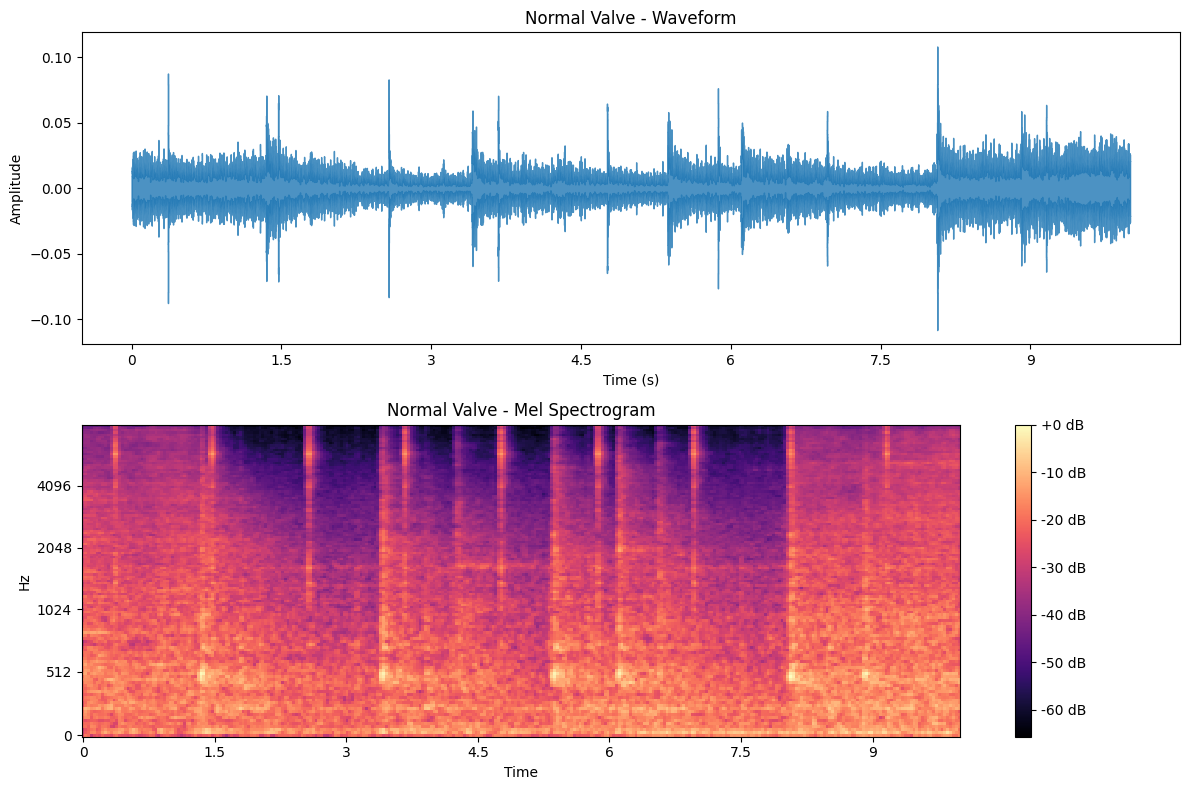

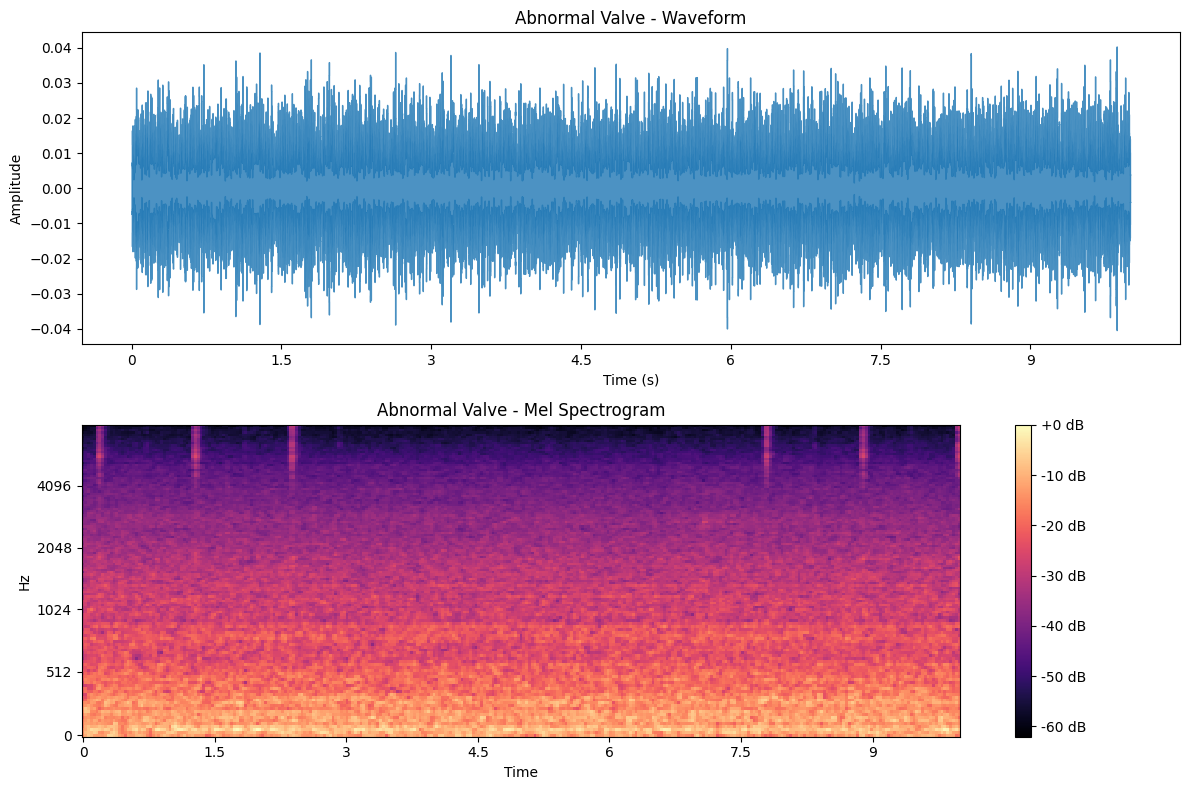

In [5]:
# 正常音と異常音のファイルパス（適当なサンプルのパスを指定）
normal_path = 'mimii_valve/valve/id_00/normal/00000000.wav'
abnormal_path = 'mimii_valve/valve/id_00/abnormal/00000000.wav'

def plot_audio_features(file_path, title_prefix):
    # 1. 音声データの読み込み (sr=Noneで元のサンプリングレートを維持)
    y, sr = librosa.load(file_path, sr=None)

    plt.figure(figsize=(12, 8))

    # 2. 波形 (Waveform) のプロット
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(y, sr=sr, alpha=0.8)
    plt.title(f'{title_prefix} - Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')

    # 3. メルスペクトログラムの計算とプロット
    # n_fft: フーリエ変換の窓サイズ, hop_length: 窓のずらし幅
    mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)

    # 振幅をデシベル（dB）スケールに変換（視覚的に特徴を捉えやすくするため）
    mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

    plt.subplot(2, 1, 2)
    librosa.display.specshow(mel_spect_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'{title_prefix} - Mel Spectrogram')

    plt.tight_layout()
    plt.show()

# 正常音の可視化
plot_audio_features(normal_path, "Normal Valve")

# 異常音の可視化
plot_audio_features(abnormal_path, "Abnormal Valve")

In [ ]:
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader
import librosa
import numpy as np

class MIMIIDataset(Dataset):
    def __init__(self, data_dir, machine_type='valve', snr='-6_dB', transform=None):
        """
        data_dir: 解凍したデータのルートディレクトリ
        """
        self.transform = transform

        # 正常音と異常音のファイルパスを取得
        # ※今回のダウンロードパスに合わせてパスを調整しています
        normal_dir = os.path.join(data_dir, machine_type, 'id_00', 'normal', '*.wav')
        abnormal_dir = os.path.join(data_dir, machine_type, 'id_00', 'abnormal', '*.wav')

        self.normal_files = glob.glob(normal_dir)
        self.abnormal_files = glob.glob(abnormal_dir)

        self.all_files = self.normal_files + self.abnormal_files

        # ラベル付け：正常を0、異常を1とする
        self.labels = [0] * len(self.normal_files) + [1] * len(self.abnormal_files)

    def __len__(self):
        return len(self.all_files)

    def __getitem__(self, idx):
        file_path = self.all_files[idx]
        label = self.labels[idx]

        # 1. 音声のロード (MIMIIは10秒のデータが多いです)
        y, sr = librosa.load(file_path, sr=16000)

        # 2. メルスペクトログラムへの変換
        mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=512, n_mels=128)
        mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

        # 3. PyTorchのTensorに変換 (モデルに入力するために [Channels, Height, Width] の形状にする)
        # 画像として扱うため、チャネル次元(1)を追加します
        feature_tensor = torch.tensor(mel_spect_db, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(label, dtype=torch.long)

        return feature_tensor, label_tensor

# データセットのインスタンス化
dataset = MIMIIDataset(data_dir='mimii_valve')

# データローダーの作成 (バッチサイズ32でシャッフルして読み込む)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# 動作テスト：1バッチ分だけ取り出して形状を確認する
for features, labels in dataloader:
    print(f"Features shape: {features.shape}") # 期待値: [32, 1, 128, T] (Tは時間軸のサイズ)
    print(f"Labels shape: {labels.shape}")     # 期待値: [32]
    break

In [ ]:
# timmライブラリのインストール
!pip install -q timm

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

class AudioViT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # timmを使って、軽量な事前学習済みViT（Tinyサイズ）をロードします。
        # in_chans=1 を指定することで、モノクロ画像（1チャンネル）を直接入力できるように
        # 最初のパッチ埋め込み層を自動で調整してくれます。（ここがtimmの超優秀な点です）
        self.vit = timm.create_model('vit_tiny_patch16_224', pretrained=True, in_chans=1, num_classes=num_classes)

    def forward(self, x):
        # 入力されたスペクトログラムのサイズ [Batch, 1, 128, 313] を、
        # ViTが規定で要求する画像サイズ [Batch, 1, 224, 224] に動的にリサイズします。
        # （これにより、元の音声の長さが多少変わってもモデルがエラーを吐かなくなります）
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)

        # ViTモデルで推論
        return self.vit(x)

# モデルのインスタンス化
model = AudioViT(num_classes=2)

# 先ほど作成したデータローダーの出力 (features) を試しに入力してみる
outputs = model(features)

print(f"Outputs shape: {outputs.shape}") # 期待される出力: [32, 2]

In [ ]:
import wandb

# APIキーを直接指定してログイン（空白などが混ざらない確実な方法です）
wandb.login(key="API＿KEY")

In [ ]:
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm

# --- 1. W&Bプロジェクトの初期化 ---
wandb.init(
    project="factory-anomaly-detection", # プロジェクト名
    name="vit-tiny-baseline",            # 今回の実験名
    config={
        "learning_rate": 1e-4,
        "architecture": "ViT-Tiny",
        "dataset": "MIMII Valve",
        "epochs": 3,
        "batch_size": 32
    }
)

# --- 2. 学習の準備 ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# GPUが使える場合はGPUに、なければCPUにモデルを転送
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# --- 3. 学習ループ ---
epochs = wandb.config.epochs

print("🚀 学習をスタートします...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    # tqdmでプログレスバーを表示
    for features, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        features, labels = features.to(device), labels.to(device)

        # 勾配の初期化と順伝播
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)

        # 逆伝播とパラメータ更新
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # W&BへバッチごとのLossをリアルタイム送信
        wandb.log({"batch_loss": loss.item()})

    # エポックごとの平均Lossを記録
    avg_loss = running_loss / len(dataloader)
    wandb.log({"epoch": epoch + 1, "epoch_loss": avg_loss})
    print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.4f}")

# W&Bの記録プロセスを終了
wandb.finish()
print("🎉 学習とW&Bへの記録が完了しました！")

In [ ]:
# モデルの重み（パラメータ）を保存する
torch.save(model.state_dict(), 'vit_anomaly_detection.pth')

print("✅ モデルの保存が完了しました！")